# F1 Regulation Change Analysis: Driver and Car Fixed Effects

Isolating driver skill from car performance across two regulation shocks —
the 2022 ground-effect regulations and the 2026 regulations — using a
two-way fixed effects model (AKM-style identification, after Abowd,
Kramarz & Margolis) on qualifying lap times.

**Circuits**: Austria (Red Bull Ring), Hungary (Hungaroring), Silverstone,
Spa-Francorchamps, and Barcelona-Catalunya. Barcelona is split into two
circuit identities either side of the 2023 chicane removal, since the
pre- and post-2023 layouts are physically different tracks.

**Seasons**: 2020–2022 (around the 2022 shock) and 2024–2026 (around the
2026 shock).

In [1]:
!pip install fastf1 linearmodels networkx --quiet --upgrade

In [2]:
import os
import warnings

import fastf1
import numpy as np
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 200)

CACHE_DIR = 'ff1_cache'
DATA_DIR = 'data'
os.makedirs(CACHE_DIR, exist_ok=True)
os.makedirs(DATA_DIR, exist_ok=True)
fastf1.Cache.enable_cache(CACHE_DIR)

print("fastf1", fastf1.__version__)

fastf1 3.8.3


## Section 1 — Circuit Configuration

`fastf1.get_event()` resolves a season + query string using **fuzzy
matching**, which can silently return the wrong event. Two real examples
found while building this:

- `'Spa'` resolves to the **Spanish** Grand Prix (Madrid) in 2026, not
  Spa-Francorchamps — it matches "España" more strongly than "Spa".
- `'Silverstone'` in 2020 resolves to the **70th Anniversary Grand Prix**,
  not the British Grand Prix. Both ran at Silverstone that year as a
  COVID-rescheduled double-header, so the query is genuinely ambiguous.

A wrong match does not raise an error — it returns a valid session for the
wrong circuit, which would silently corrupt the panel. So each circuit
declares an **`expected_location`**, and every resolution is validated
against it before any data is pulled. Per-season `overrides` accept either
a different query string or an integer round number, which is unambiguous.

In [3]:
CIRCUITS = {
    'Austria': {
        'query': 'Austria',
        'expected_location': 'Spielberg',
        'seasons': [2018, 2019, 2020, 2021, 2022, 2023, 2024, 2025, 2026],
    },
    'Hungary': {
        'query': 'Hungary',
        'expected_location': 'Budapest',
        'seasons': [2018, 2019, 2020, 2021, 2022, 2023, 2024, 2025, 2026],
    },
    'Silverstone': {
        'query': 'Silverstone',
        'expected_location': 'Silverstone',
        'seasons': [2018, 2019, 2020, 2021, 2022, 2023, 2024, 2025, 2026],
        # 2020 ran two races here; round 4 is the British GP proper.
        'overrides': {2020: 4},
    },
    'Spa': {
        'query': 'Belgium',
        'expected_location': 'Spa-Francorchamps',
        'seasons': [2018, 2019, 2020, 2021, 2022, 2023, 2024, 2025, 2026],
    },
    'Barcelona_pre2023': {
        'query': 'Barcelona',
        'expected_location': 'Barcelona',
        'seasons': [2018, 2019, 2020, 2021, 2022],
    },
    'Barcelona_post2023': {
        'query': 'Barcelona',
        'expected_location': 'Barcelona',
        'seasons': [2023, 2024, 2025, 2026],
    },
}

def get_query(cfg, season):
    """Resolve the lookup key for a circuit-season, honouring overrides."""
    return cfg.get('overrides', {}).get(season, cfg['query'])

TARGETS = [(cid, s) for cid, cfg in CIRCUITS.items() for s in cfg['seasons']]
print(f"{len(CIRCUITS)} circuit identities, {len(TARGETS)} circuit-seasons")

6 circuit identities, 45 circuit-seasons


## Section 2 — Resolution Audit

This resolves every circuit-season to a concrete event and checks the
location against `expected_location` **without downloading any session
data**. It is fast, and it is the gate: if anything fails here, fix the
config before pulling. Pulling first and checking later means silently
building the panel on the wrong races.

In [4]:
audit_rows = []
for circuit_id, cfg in CIRCUITS.items():
    for season in cfg['seasons']:
        query = get_query(cfg, season)
        try:
            ev = fastf1.get_event(season, query)
            loc = ev['Location']
            ok = cfg['expected_location'].lower() in str(loc).lower()
            audit_rows.append({
                'CircuitID': circuit_id, 'Season': season, 'Query': query,
                'ResolvedEvent': ev['EventName'], 'Location': loc,
                'Round': ev['RoundNumber'], 'Format': ev['EventFormat'],
                'OK': ok,
            })
        except Exception as e:
            audit_rows.append({
                'CircuitID': circuit_id, 'Season': season, 'Query': query,
                'ResolvedEvent': f'ERROR: {type(e).__name__}', 'Location': None,
                'Round': None, 'Format': None, 'OK': False,
            })

audit = pd.DataFrame(audit_rows)
print(audit.to_string(index=False))

bad = audit[~audit['OK']]
print()
if len(bad):
    print(f"*** {len(bad)} FAILED VALIDATION — fix config before pulling ***")
    print(bad[['CircuitID', 'Season', 'Query', 'ResolvedEvent', 'Location']].to_string(index=False))
else:
    print("All circuit-seasons resolved to the expected location.")

events      WARNING 	Correcting user input 'Austria' to 'Austrian Grand Prix'
events      WARNING 	Correcting user input 'Austria' to 'Austrian Grand Prix'


         CircuitID  Season       Query        ResolvedEvent          Location  Round            Format   OK
           Austria    2018     Austria  Austrian Grand Prix         Spielberg      9      conventional True
           Austria    2019     Austria  Austrian Grand Prix         Spielberg      9      conventional True
           Austria    2020     Austria  Austrian Grand Prix         Spielberg      1      conventional True
           Austria    2021     Austria  Austrian Grand Prix         Spielberg      9      conventional True
           Austria    2022     Austria  Austrian Grand Prix         Spielberg     11            sprint True
           Austria    2023     Austria  Austrian Grand Prix         Spielberg      9   sprint_shootout True
           Austria    2024     Austria  Austrian Grand Prix         Spielberg     11 sprint_qualifying True
           Austria    2025     Austria  Austrian Grand Prix         Spielberg     11      conventional True
           Austria    2026  

## Section 3 — Data Pull

For each validated circuit-season, this loads the **knockout qualifying**
session. `event.get_qualifying()` always returns the single-lap knockout
session, including on sprint weekends — in 2021–22 the *Saturday race* was
briefly branded "Sprint Qualifying", but that is a race, not this session,
and fastf1 resolves the naming internally.

Lap times are stored as **floats in seconds** (`LapTimeSeconds`) rather
than as pandas timedeltas, because timedeltas do not survive a CSV
round-trip cleanly and these files are written to disk as checkpoints.

All laps are kept at this stage — filtering happens in Section 4, so the
filtering decisions are visible and auditable rather than buried in the
download step. Set `FORCE_REFRESH = True` to re-pull a circuit-season that
is already cached.

In [5]:
FORCE_REFRESH = False

WEATHER_COLS = ['AirTemp', 'TrackTemp', 'Humidity', 'Pressure',
                'WindSpeed', 'WindDirection', 'Rainfall']

KEEP_LAP_COLS = ['Driver', 'DriverNumber', 'Team', 'LapNumber', 'Stint',
                 'Compound', 'TyreLife', 'TrackStatus', 'IsAccurate', 'Deleted']

def pull_qualifying(circuit_id, query, season):
    """Return a tidy DataFrame of all qualifying laps for one circuit-season."""
    event = fastf1.get_event(season, query)
    session = event.get_qualifying()
    session.load()

    laps = session.laps.copy()
    if laps.empty:
        raise ValueError("session returned zero laps")

    laps['LapTimeSeconds'] = laps['LapTime'].dt.total_seconds()

    cols = [c for c in KEEP_LAP_COLS if c in laps.columns]
    out = laps[cols + ['LapTimeSeconds', 'Time']].copy()

    weather = session.weather_data
    if weather is not None and not weather.empty:
        wcols = ['Time'] + [c for c in WEATHER_COLS if c in weather.columns]
        out = pd.merge_asof(
            out.sort_values('Time'),
            weather[wcols].sort_values('Time'),
            on='Time', direction='nearest',
        )
    else:
        for c in WEATHER_COLS:
            out[c] = np.nan

    out = out.drop(columns=['Time'])
    out['CircuitID'] = circuit_id
    out['Season'] = season
    out['RoundNumber'] = event['RoundNumber']
    out['EventName'] = event['EventName']
    out['EventFormat'] = event['EventFormat']
    out['IsSprintWeekend'] = event['EventFormat'] != 'conventional'
    return out


frames = []
for circuit_id, cfg in CIRCUITS.items():
    for season in cfg['seasons']:
        path = f"{DATA_DIR}/{circuit_id}_{season}.csv"

        if os.path.exists(path) and not FORCE_REFRESH:
            frames.append(pd.read_csv(path))
            print(f"[cached] {circuit_id} {season}")
            continue

        query = get_query(cfg, season)
        try:
            df = pull_qualifying(circuit_id, query, season)
            df.to_csv(path, index=False)
            frames.append(df)
            print(f"[ok]     {circuit_id} {season}: {len(df)} laps "
                  f"({df['EventName'].iloc[0]}, round {df['RoundNumber'].iloc[0]})")
        except Exception as e:
            print(f"[FAIL]   {circuit_id} {season}: {type(e).__name__}: {e}")

raw_panel = pd.concat(frames, ignore_index=True)
print(f"\nraw_panel: {len(raw_panel)} laps across {len(frames)} circuit-seasons")

[cached] Austria 2018
[cached] Austria 2019
[cached] Austria 2020
[cached] Austria 2021
[cached] Austria 2022
[cached] Austria 2023
[cached] Austria 2024
[cached] Austria 2025
[cached] Austria 2026
[cached] Hungary 2018
[cached] Hungary 2019
[cached] Hungary 2020
[cached] Hungary 2021
[cached] Hungary 2022
[cached] Hungary 2023
[cached] Hungary 2024
[cached] Hungary 2025
[cached] Hungary 2026
[cached] Silverstone 2018
[cached] Silverstone 2019
[cached] Silverstone 2020
[cached] Silverstone 2021
[cached] Silverstone 2022
[cached] Silverstone 2023
[cached] Silverstone 2024
[cached] Silverstone 2025
[cached] Silverstone 2026
[cached] Spa 2018
[cached] Spa 2019
[cached] Spa 2020
[cached] Spa 2021
[cached] Spa 2022
[cached] Spa 2023
[cached] Spa 2024
[cached] Spa 2025
[cached] Spa 2026
[cached] Barcelona_pre2023 2018
[cached] Barcelona_pre2023 2019
[cached] Barcelona_pre2023 2020
[cached] Barcelona_pre2023 2021
[cached] Barcelona_pre2023 2022
[cached] Barcelona_post2023 2023
[cached] Barcel

In [6]:
loaded = set(map(tuple, raw_panel[['CircuitID', 'Season']].drop_duplicates().values))
missing = [t for t in TARGETS if t not in loaded]

print(f"Loaded {len(loaded)} / {len(TARGETS)} circuit-seasons")
if missing:
    print("MISSING:", missing)
else:
    print("No gaps.")

# Confirm what actually landed on disk matches what was intended.
print()
provenance = (raw_panel
              .groupby(['CircuitID', 'Season'])
              .agg(EventName=('EventName', 'first'),
                   Round=('RoundNumber', 'first'),
                   Sprint=('IsSprintWeekend', 'first'),
                   Laps=('LapTimeSeconds', 'size'),
                   Drivers=('Driver', 'nunique'))
              .reset_index())
print(provenance.to_string(index=False))

Loaded 45 / 45 circuit-seasons
No gaps.

         CircuitID  Season            EventName  Round  Sprint  Laps  Drivers
           Austria    2018  Austrian Grand Prix      9   False   331       20
           Austria    2019  Austrian Grand Prix      9   False   314       20
           Austria    2020  Austrian Grand Prix      1   False   298       20
           Austria    2021  Austrian Grand Prix      9   False   299       20
           Austria    2022  Austrian Grand Prix     11    True   368       20
           Austria    2023  Austrian Grand Prix      9    True   377       20
           Austria    2024  Austrian Grand Prix     11    True   320       20
           Austria    2025  Austrian Grand Prix     11   False   310       20
           Austria    2026  Austrian Grand Prix      8   False   289       22
Barcelona_post2023    2023   Spanish Grand Prix      7   False   337       20
Barcelona_post2023    2024   Spanish Grand Prix     10   False   257       20
Barcelona_post2023    2

## Section 3b — Qualifying Segment Times

Qualifying runs in three segments and the track rubbers in throughout. Measured
on this panel, the same driver's Q3 lap is a median **0.91%** of a lap quicker
than their own Q1 lap (IQR 0.47–1.38%) — roughly eight tenths at Silverstone.

That matters because a driver knocked out in Q1 sets their best lap on a green
track while a driver who reaches Q3 sets theirs half an hour later on a fully
rubbered one. Comparing those two as if conditions were equal charges the Q1
driver for track evolution and books it as lack of pace. Since the drivers who
exit early cluster in the slower teams, the bias is systematic, not noise.

`session.results` carries each driver's official best time in each segment as
separate `Q1`, `Q2` and `Q3` columns. Those are pulled here so every lap can be
labelled with the segment it was set in, and the evolution absorbed by a fixed
effect in Section 6 rather than left in the driver term.

In [7]:
SEG_PATH = f"{DATA_DIR}/_segment_times.csv"

def pull_segments(circuit_id, query, season):
    event = fastf1.get_event(season, query)
    s = event.get_qualifying()
    s.load(telemetry=False, weather=False, messages=False)
    r = s.results[['Abbreviation', 'Q1', 'Q2', 'Q3']].copy()
    for q in ['Q1', 'Q2', 'Q3']:
        r[q] = r[q].dt.total_seconds()
    r = r.rename(columns={'Abbreviation': 'Driver'})
    r['CircuitID'] = circuit_id
    r['Season'] = season
    return r


if os.path.exists(SEG_PATH) and not FORCE_REFRESH:
    segment_times = pd.read_csv(SEG_PATH)
    print(f"[cached] segment times: {len(segment_times)} driver-sessions")
else:
    seg_frames = []
    for circuit_id, cfg in CIRCUITS.items():
        for season in cfg['seasons']:
            try:
                seg_frames.append(pull_segments(circuit_id, get_query(cfg, season), season))
                print(f"[ok]   {circuit_id} {season}")
            except Exception as e:
                print(f"[FAIL] {circuit_id} {season}: {type(e).__name__}: {e}")
    segment_times = pd.concat(seg_frames, ignore_index=True)
    segment_times.to_csv(SEG_PATH, index=False)
    print(f"\nsegment times: {len(segment_times)} driver-sessions")

deepest = np.where(segment_times['Q3'].notna(), 'Q3',
           np.where(segment_times['Q2'].notna(), 'Q2', 'Q1'))
print("\ndeepest segment reached:")
print(pd.Series(deepest).value_counts().to_string())

[cached] segment times: 910 driver-sessions

deepest segment reached:
Q3    442
Q1    235
Q2    233


## Section 4 — Cleaning & Normalization

In [8]:
SESSION_KEYS = ['CircuitID', 'Season']
WET_TYRES = ['INTERMEDIATE', 'WET']

clean = raw_panel.copy()

# --- 1. laps with no recorded time are unusable ---
n0 = len(clean)
clean = clean[clean['LapTimeSeconds'].notna()]
print(f"dropped {n0 - len(clean):5d} laps with no lap time")

# --- 2. classify session conditions BEFORE any other filtering ---
# Order matters: doing this after the accuracy filter previously let Spa 2021
# through, because the laps carrying the rain signal were the ones removed.
#
# The compound is used rather than the `Rainfall` sensor. `Rainfall` reports
# whether precipitation is falling at that instant, which is False on a soaked
# but drying track (Spa 2021) and True when it rains around a session whose
# timed laps were all on slicks (Hungary 2024: 81% rain samples, zero wet-tyre
# laps). Teams fit inters or wets only when the track is genuinely wet.
#
# A session is excluded if ANY driver's best lap was set on a wet-weather tyre,
# not merely the pole lap. Testing pole alone kept mixed, drying sessions where
# the front of the grid ran late on slicks while drivers eliminated earlier were
# stuck with damp-track times. Silverstone 2024 was such a session: pole on
# softs, 10% of the field on inters, and Magnussen 8.3% off pole -- roughly
# seven seconds, which is not a car or driver effect but a compromised lap.
prov = clean.loc[clean.groupby(SESSION_KEYS + ['Driver'])['LapTimeSeconds'].idxmin()]
wet_any = prov[prov['Compound'].isin(WET_TYRES)].groupby(SESSION_KEYS).size()
wet_sessions = set(wet_any.index)

print("\nsessions excluded (any driver's best lap on a wet tyre):")
if wet_sessions:
    for k in sorted(wet_sessions):
        print(f"  {k}: {int(wet_any[k])} of "
              f"{int((prov.set_index(SESSION_KEYS).index == k).sum())} drivers on wets")
else:
    print("  none")

n1 = len(clean)
clean = clean[~clean.set_index(SESSION_KEYS).index.isin(wet_sessions)]
print(f"\ndropped {n1 - len(clean):5d} laps from mixed or wet sessions")

# --- 3. lap-level quality filters ---
n2 = len(clean)
if 'Deleted' in clean.columns:
    clean = clean[clean['Deleted'] != True]
print(f"dropped {n2 - len(clean):5d} deleted laps (track limits)")

n3 = len(clean)
if 'IsAccurate' in clean.columns:
    clean = clean[clean['IsAccurate'] == True]
print(f"dropped {n3 - len(clean):5d} laps not marked accurate (out/in laps, flags, timing errors)")

print(f"\nremaining: {len(clean)} laps across {clean.groupby(SESSION_KEYS).ngroups} circuit-seasons")

dropped  4558 laps with no lap time

sessions excluded (any driver's best lap on a wet tyre):
  ('Silverstone', 2022): 20 of 20 drivers on wets
  ('Silverstone', 2024): 2 of 20 drivers on wets
  ('Spa', 2021): 20 of 20 drivers on wets
  ('Spa', 2023): 6 of 20 drivers on wets
  ('Spa', 2024): 20 of 20 drivers on wets

dropped  1286 laps from mixed or wet sessions
dropped   126 deleted laps (track limits)
dropped  3413 laps not marked accurate (out/in laps, flags, timing errors)

remaining: 4298 laps across 40 circuit-seasons


In [9]:
OUTLIER_PCT = 5.0

best = clean.loc[clean.groupby(SESSION_KEYS + ['Driver'])['LapTimeSeconds'].idxmin()].copy()
best = best.reset_index(drop=True)

# --- label each best lap with the segment it was actually set in ---
# Note this is the segment of the driver's best lap, not the deepest segment
# reached: a driver who botches their Q3 run keeps their Q2 time, and it is the
# track condition when the lap was set that matters here.
best = best.merge(segment_times, on=['CircuitID', 'Season', 'Driver'], how='left')

def assign_segment(row):
    avail = {q: row[q] for q in ('Q1', 'Q2', 'Q3') if pd.notna(row[q])}
    if not avail:
        return 'UNKNOWN', np.nan
    seg = min(avail, key=lambda q: abs(avail[q] - row['LapTimeSeconds']))
    return seg, abs(avail[seg] - row['LapTimeSeconds'])

lab = best.apply(assign_segment, axis=1, result_type='expand')
best['BestSegment'] = lab[0]
best['SegmentMatchErr'] = lab[1]

print(f"segment assigned within 0.05s for "
      f"{int((best['SegmentMatchErr'] < 0.05).sum())}/{len(best)} rows")
print(best['BestSegment'].value_counts().to_string())

unplaced = best['BestSegment'].eq('UNKNOWN') | best['SegmentMatchErr'].ge(0.05)
if unplaced.any():
    print(f"\ndropping {int(unplaced.sum())} rows with no reliable segment match")
    best = best[~unplaced].reset_index(drop=True)

best['PoleTime'] = best.groupby(SESSION_KEYS)['LapTimeSeconds'].transform('min')
best['GapToPole'] = best['LapTimeSeconds'] - best['PoleTime']
best['PctOffPole'] = 100 * best['GapToPole'] / best['PoleTime']

# --- trim residual outliers ---
# Pole-to-last spread in a clean dry qualifying session runs about 3-4% of a
# lap. Anything beyond 5% is an aborted lap, a lap ruined by traffic or a yellow,
# or a damp window that survived the session-level filter. Least squares weights
# these hardest, so a single such lap can move a driver effect by whole
# percentage points and force the car effect the other way to compensate.
bad = best['PctOffPole'] > OUTLIER_PCT
if bad.any():
    print(f"\ndropping {int(bad.sum())} driver-sessions over {OUTLIER_PCT}% off pole:")
    print(best.loc[bad, SESSION_KEYS + ['Driver', 'Team', 'BestSegment', 'PctOffPole']]
              .sort_values('PctOffPole', ascending=False).round(2).to_string(index=False))
    best = best[~bad].reset_index(drop=True)
    # pole is unchanged by the trim (it is the fastest lap), so gaps stand

print(f"\n{len(best)} driver-session rows across "
      f"{best.groupby(SESSION_KEYS).ngroups} circuit-seasons")

assert (best['GapToPole'] >= -1e-6).all(), "negative gap -- pole logic wrong"
assert best.groupby(SESSION_KEYS + ['Driver']).size().max() == 1, "duplicate driver-session rows"
print("sanity checks passed")

segment assigned within 0.05s for 793/799 rows
BestSegment
Q3    283
Q1    269
Q2    247

dropping 6 rows with no reliable segment match

dropping 18 driver-sessions over 5.0% off pole:
         CircuitID  Season Driver         Team BestSegment  PctOffPole
           Hungary    2018    HUL      Renault          Q2       25.88
           Hungary    2018    ALO      McLaren          Q2       24.19
           Hungary    2018    GRO Haas F1 Team          Q2       22.15
           Hungary    2018    HAM     Mercedes          Q2       19.01
           Hungary    2018    SAI      Renault          Q2       18.40
       Silverstone    2023    MAG Haas F1 Team          Q1        6.52
 Barcelona_pre2023    2019    KUB     Williams          Q1        6.43
           Austria    2026    STR Aston Martin          Q1        6.43
           Austria    2026    ALO Aston Martin          Q1        5.79
       Silverstone    2026    ALO Aston Martin          Q1        5.58
               Spa    2026    STR

## Section 5 — Connectivity Analysis

The two-way fixed effects model separates driver skill from car performance
using drivers as the link between cars. The unit for "car" is the
**team-season** (a 2021 Red Bull and a 2022 Red Bull are different cars),
and two team-seasons are connected when the same driver appears in both.

Two kinds of edge both matter:

- **Across teams** — Bottas at Mercedes 2021 and Alfa Romeo 2022 links
  those two cars.
- **Across seasons at one team** — Verstappen at Red Bull 2021 and 2022
  links those two cars, and that link is what identifies the regulation
  effect itself.

Only team-seasons inside the **largest connected component** have car
effects estimable on a common scale. An isolated group is internally
consistent but floats on its own scale, so its numbers cannot be compared
against the rest of the grid. Those are reported by name and excluded from
the regression rather than dropped silently.

Connectivity is computed **separately per window**, because the two
regulation shocks are estimated as two independent models.

In [10]:
ALL_SEASONS = [2018, 2019, 2020, 2021, 2022, 2023, 2024, 2025, 2026]

# The two transitions the paper reports on. 2023 is NOT a reported year -- it is
# the bridge that connects the pre-2022 era to the post-2024 era, so that both
# shocks land on one common scale instead of two incomparable ones.
SHOCKS = {'2022_shock': (2021, 2022), '2026_shock': (2025, 2026)}


def build_car_graph(panel):
    G = nx.Graph()
    for cs in panel[['Season', 'Team']].drop_duplicates().itertuples(index=False):
        G.add_node((cs.Season, cs.Team))
    for driver, g in panel.groupby('Driver'):
        nodes = sorted(set(zip(g['Season'], g['Team'])))
        for i in range(len(nodes)):
            for j in range(i + 1, len(nodes)):
                if G.has_edge(nodes[i], nodes[j]):
                    G[nodes[i]][nodes[j]]['via'].append(driver)
                else:
                    G.add_edge(nodes[i], nodes[j], via=[driver])
    return G


# ONE graph over every season. The extra years exist to identify driver skill;
# they are not filtered out before estimation.
G = build_car_graph(best)
comps = sorted(nx.connected_components(G), key=len, reverse=True)
main_component = comps[0] if comps else set()

print(f"{len(best)} driver-session rows | {G.number_of_nodes()} team-seasons "
      f"| {len(comps)} component(s), sizes={[len(c) for c in comps]}")
for c in comps[1:]:
    print(f"    isolated (excluded): {sorted(c)}")

best['InMainComponent'] = [(r.Season, r.Team) in main_component
                           for r in best.itertuples(index=False)]
kept = int(best['InMainComponent'].sum())
print(f"\nestimable rows: {kept}/{len(best)}   ({len(best) - kept} excluded)")

print("\ncoverage of the reported years within the main component:")
rep = best[best['InMainComponent'] & best['Season'].isin(
    [2020, 2021, 2022, 2024, 2025, 2026])]
print(rep.groupby('Season').agg(rows=('Driver', 'size'),
                                teams=('Team', 'nunique'),
                                drivers=('Driver', 'nunique')).to_string())


775 driver-session rows | 92 team-seasons | 1 component(s), sizes=[92]

estimable rows: 775/775   (0 excluded)

coverage of the reported years within the main component:
        rows  teams  drivers
Season                      
2020     100     10       21
2021      79     10       20
2022      79     10       20
2024      60     10       20
2025     100     10       20
2026     101     11       22


The edges that carry identification are listed below. Moves between teams
are the strongest links, since they place two different cars under the same
driver in overlapping conditions.

In [11]:
print("driver moves between teams (the edges that identify driver skill):\n")
moves = []
for a, b, data in G.edges(data=True):
    if a[1] != b[1]:
        for d in data['via']:
            moves.append((d, min(a[0], b[0]), f"{a[1]} {a[0]}", f"{b[1]} {b[0]}"))
for d, _, frm, to in sorted(moves, key=lambda m: (m[0], m[1])):
    print(f"  {d}: {frm}  <->  {to}")
print(f"\n{len(moves)} switch edges, {len(set(m[0] for m in moves))} distinct drivers")


driver moves between teams (the edges that identify driver skill):

  ALB: Toro Rosso 2019  <->  Red Bull Racing 2019
  ALB: Toro Rosso 2019  <->  Red Bull Racing 2020
  ALB: Toro Rosso 2019  <->  Williams 2022
  ALB: Toro Rosso 2019  <->  Williams 2023
  ALB: Toro Rosso 2019  <->  Williams 2024
  ALB: Toro Rosso 2019  <->  Williams 2025
  ALB: Toro Rosso 2019  <->  Williams 2026
  ALB: Red Bull Racing 2019  <->  Williams 2022
  ALB: Red Bull Racing 2019  <->  Williams 2023
  ALB: Red Bull Racing 2019  <->  Williams 2024
  ALB: Red Bull Racing 2019  <->  Williams 2025
  ALB: Red Bull Racing 2019  <->  Williams 2026
  ALB: Red Bull Racing 2020  <->  Williams 2022
  ALB: Red Bull Racing 2020  <->  Williams 2023
  ALB: Red Bull Racing 2020  <->  Williams 2024
  ALB: Red Bull Racing 2020  <->  Williams 2025
  ALB: Red Bull Racing 2020  <->  Williams 2026
  ALO: McLaren 2018  <->  Alpine 2021
  ALO: McLaren 2018  <->  Alpine 2022
  ALO: McLaren 2018  <->  Aston Martin 2023
  ALO: McLaren 20

The connectivity graph below is a poster figure. Blue nodes are team-seasons
whose car effects are estimable on a common scale; red nodes are isolated and
excluded from the regression.

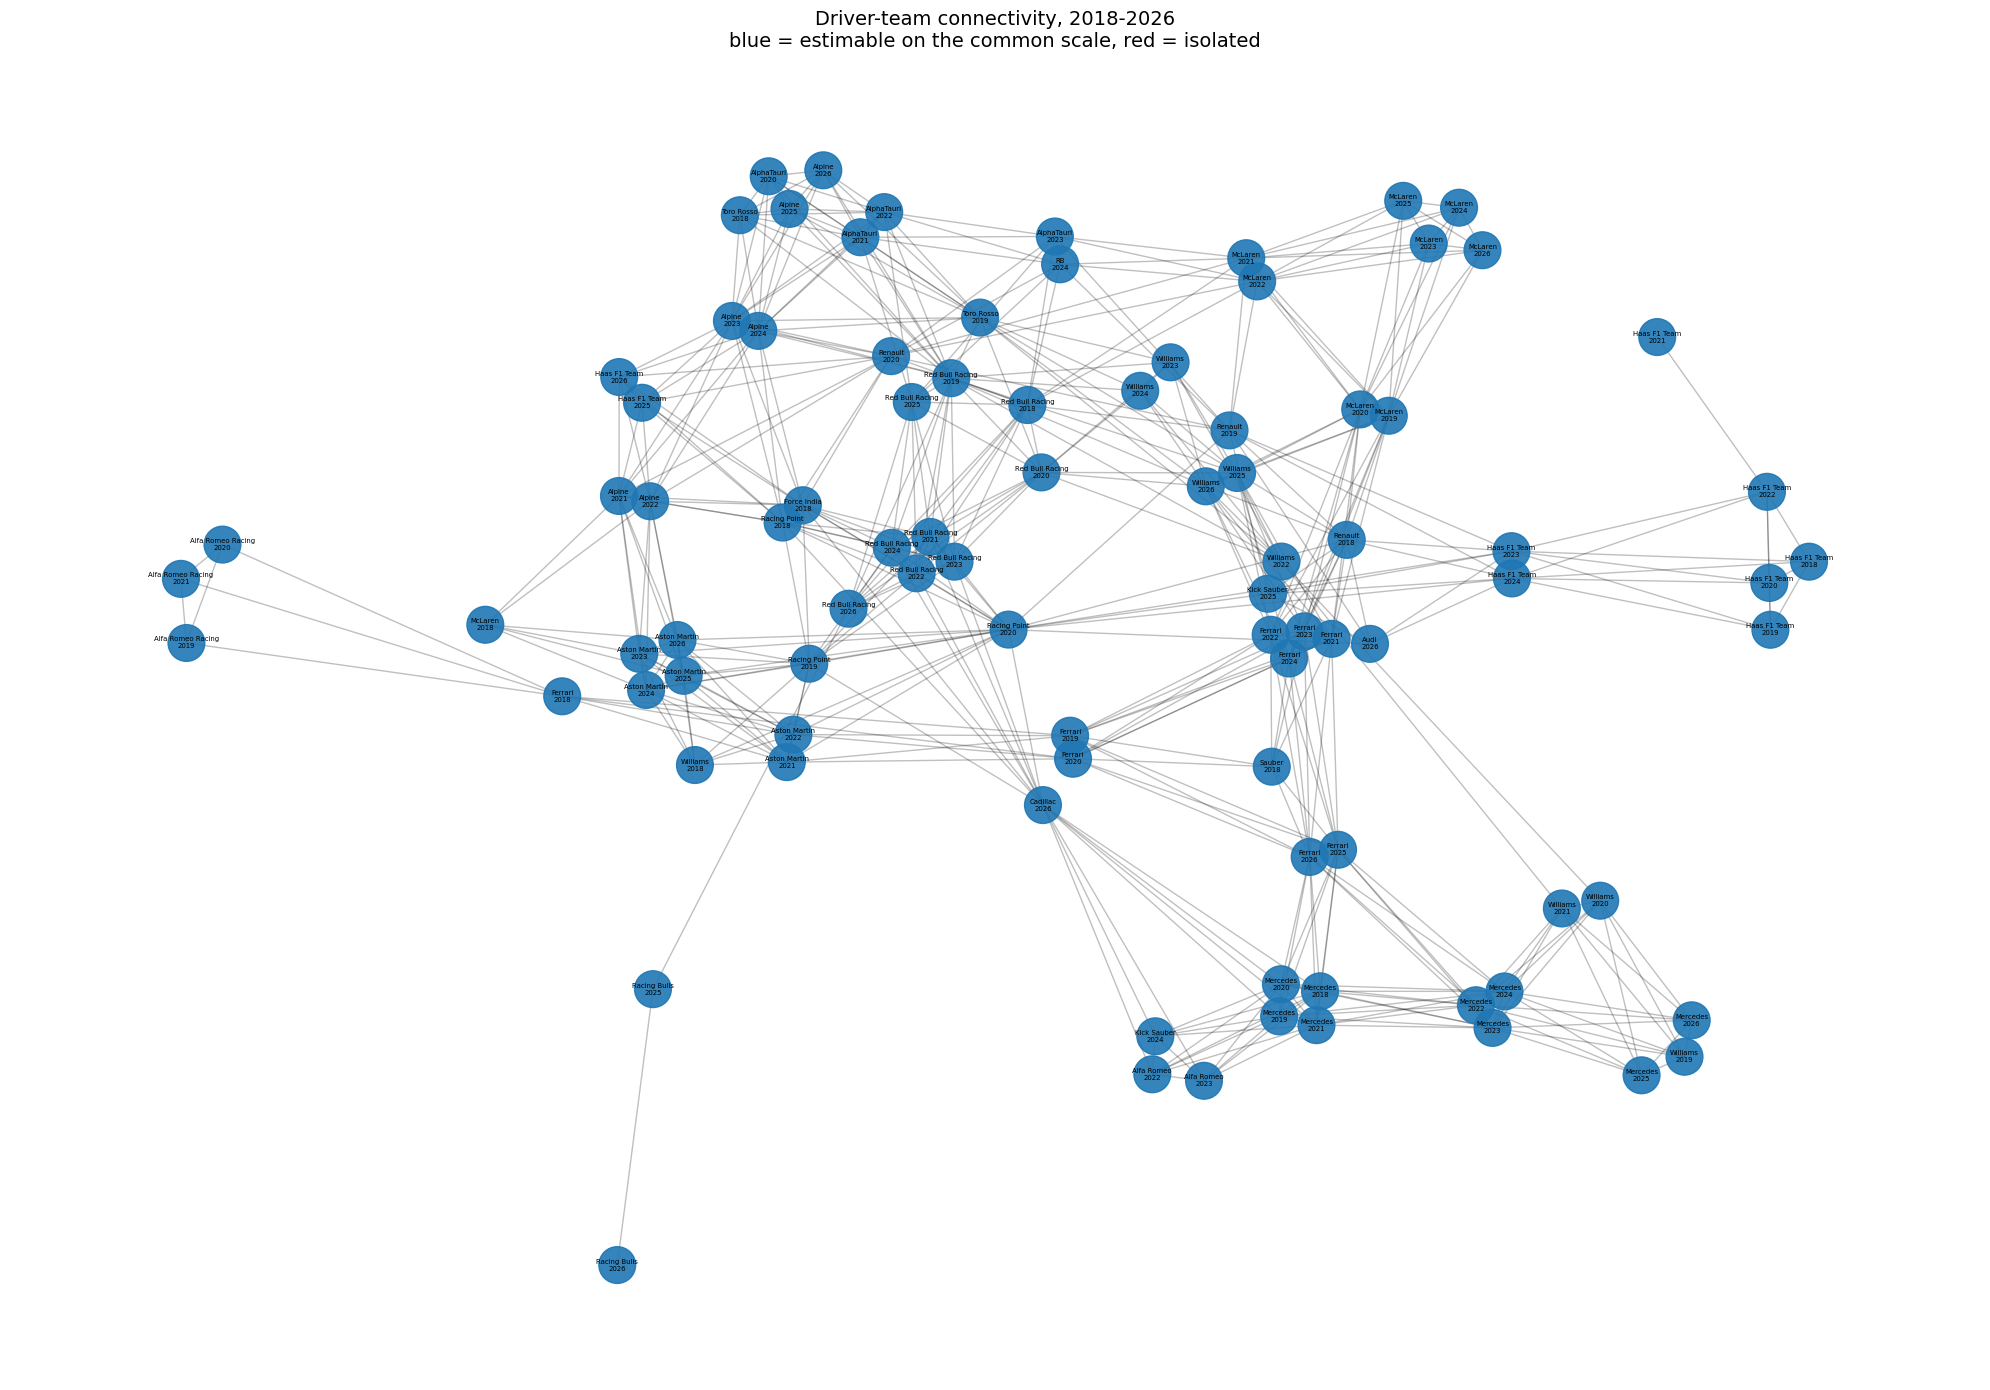

In [12]:
fig, ax = plt.subplots(figsize=(20, 14))

colors = ['#1f77b4' if n in main_component else '#d62728' for n in G.nodes]
pos = nx.spring_layout(G, seed=42, k=0.55, iterations=120)

nx.draw_networkx_edges(G, pos, ax=ax, alpha=0.25)
nx.draw_networkx_nodes(G, pos, ax=ax, node_color=colors, node_size=700, alpha=0.9)
nx.draw_networkx_labels(G, pos, ax=ax,
                        labels={n: f"{n[1]}\n{n[0]}" for n in G.nodes}, font_size=5)
ax.set_title("Driver-team connectivity, 2018-2026\n"
             "blue = estimable on the common scale, red = isolated", fontsize=14)
ax.axis('off')
plt.tight_layout()
plt.savefig('connectivity_graph.png', dpi=200, bbox_inches='tight')
plt.show()


In [13]:
for name, (pre, post) in SHOCKS.items():
    sub = best[best['InMainComponent'] & best['Season'].isin([pre, post])]
    print(f"{name} ({pre} vs {post}): {len(sub)} rows | "
          f"{sub['Team'].nunique()} teams | {sub['Driver'].nunique()} drivers | "
          f"{sub.groupby(SESSION_KEYS).ngroups} circuit-seasons")
    for s in (pre, post):
        t = sorted(sub[sub['Season'] == s]['Team'].unique())
        print(f"    {s}: {len(t)} teams -> {t}")
    print()


2022_shock (2021 vs 2022): 158 rows | 11 teams | 23 drivers | 8 circuit-seasons
    2021: 10 teams -> ['Alfa Romeo Racing', 'AlphaTauri', 'Alpine', 'Aston Martin', 'Ferrari', 'Haas F1 Team', 'McLaren', 'Mercedes', 'Red Bull Racing', 'Williams']
    2022: 10 teams -> ['Alfa Romeo', 'AlphaTauri', 'Alpine', 'Aston Martin', 'Ferrari', 'Haas F1 Team', 'McLaren', 'Mercedes', 'Red Bull Racing', 'Williams']

2026_shock (2025 vs 2026): 201 rows | 12 teams | 23 drivers | 10 circuit-seasons
    2025: 10 teams -> ['Alpine', 'Aston Martin', 'Ferrari', 'Haas F1 Team', 'Kick Sauber', 'McLaren', 'Mercedes', 'Racing Bulls', 'Red Bull Racing', 'Williams']
    2026: 11 teams -> ['Alpine', 'Aston Martin', 'Audi', 'Cadillac', 'Ferrari', 'Haas F1 Team', 'McLaren', 'Mercedes', 'Racing Bulls', 'Red Bull Racing', 'Williams']



In [14]:
# Which teams/drivers are estimable in the reported years
rep = best[best['InMainComponent'] & best['Season'].isin([2020, 2021, 2022, 2024, 2025, 2026])]
print("teams on the common scale, by reported season:\n")
print(rep.groupby(['Season', 'Team'])['Driver']
         .apply(lambda s: sorted(s.unique())).to_string())


teams on the common scale, by reported season:

Season  Team             
2020    Alfa Romeo Racing         [GIO, RAI]
        AlphaTauri                [GAS, KVY]
        Ferrari                   [LEC, VET]
        Haas F1 Team              [GRO, MAG]
        McLaren                   [NOR, SAI]
        Mercedes                  [BOT, HAM]
        Racing Point         [HUL, PER, STR]
        Red Bull Racing           [ALB, VER]
        Renault                   [OCO, RIC]
        Williams                  [LAT, RUS]
2021    Alfa Romeo Racing         [GIO, RAI]
        AlphaTauri                [GAS, TSU]
        Alpine                    [ALO, OCO]
        Aston Martin              [STR, VET]
        Ferrari                   [LEC, SAI]
        Haas F1 Team              [MAZ, MSC]
        McLaren                   [NOR, RIC]
        Mercedes                  [BOT, HAM]
        Red Bull Racing           [PER, VER]
        Williams                  [LAT, RUS]
2022    Alfa Romeo        

In [36]:
TEAM_ALIAS = {
    'Alfa Romeo Racing': 'Sauber/Alfa/Kick/Audi',
    'Alfa Romeo':         'Sauber/Alfa/Kick/Audi',
    'Kick Sauber':        'Sauber/Alfa/Kick/Audi',
    'Audi':                'Sauber/Alfa/Kick/Audi',
}

car_tbl['Team'] = car_tbl['Team'].replace(TEAM_ALIAS)
print("teams present per season after aliasing:")
print(car_tbl.groupby('Season')['Team'].apply(lambda s: sorted(s.unique())).to_string())

teams present per season after aliasing:
Season
2018    [Ferrari, Force India, Haas F1 Team, McLaren, ...
2019    [Ferrari, Haas F1 Team, McLaren, Mercedes, Rac...
2020    [AlphaTauri, Ferrari, Haas F1 Team, McLaren, M...
2021    [AlphaTauri, Alpine, Aston Martin, Ferrari, Ha...
2022    [AlphaTauri, Alpine, Aston Martin, Ferrari, Ha...
2023    [AlphaTauri, Alpine, Aston Martin, Ferrari, Ha...
2024    [Alpine, Aston Martin, Ferrari, Haas F1 Team, ...
2025    [Alpine, Aston Martin, Ferrari, Haas F1 Team, ...
2026    [Alpine, Aston Martin, Cadillac, Ferrari, Haas...


## Section 6 — Two-Way Fixed Effects Model

Qualifying pace is modelled as

    PctOffPole = driver effect + car effect + segment effect + error

where `car` is the team-season. The **segment effect** absorbs track evolution:
it estimates how much of a lap set in Q1 or Q2 is slower purely because the
track was less rubbered, so that deficit is no longer charged to the driver.
Without it, drivers who exit in Q1 — who cluster in the slower teams — absorb
the evolution as apparent lack of skill, and the car effect swings the other
way to compensate.

The full 2018–2026 panel is used for estimation so driver effects are pinned
down by as many team switches as possible; only the transition years are
reported.

`PctOffPole` is measured against each session's own pole lap, so a change
affecting every car equally is invisible here. What is identified is movement
**relative to the field**, not absolute pace. Driver and car effects are
centred on zero and are only jointly identified up to a constant.

In [37]:
import statsmodels.api as sm

MIN_SESSIONS = 5

model_df = best[best['InMainComponent']].copy()
model_df['CarUnit'] = model_df['Team'] + '_' + model_df['Season'].astype(str)

# Drivers with very few sessions get noisy, extreme fixed effects that trade off
# against the car effects they touch -- the limited-mobility problem in AKM
# models. Kubica ranking 4th fastest on the grid off a single session is not a
# finding. Pooling them into one shared OTHER term keeps their observations, so
# team-seasons that depend on them survive, without giving any of them a rank.
#
# The threshold is set so that no team-season loses both its drivers: at 8,
# Haas 2021 (Schumacher 7, Mazepin 4) would have no individually-estimated
# driver at all, and it is the "before" side of the 2022 shock.
#
# Cost of pooling: all rare drivers are assumed to share one skill level, which
# links the team-seasons they drove for. Dropping them instead would delete
# Haas 2021 outright.
counts = model_df['Driver'].value_counts()
rare = sorted(counts[counts < MIN_SESSIONS].index)
model_df['DriverKey'] = model_df['Driver'].where(~model_df['Driver'].isin(rare), 'OTHER')

print(f"pooled {len(rare)} drivers with <{MIN_SESSIONS} sessions into OTHER:")
for d in rare:
    print(f"  {d}: {int(counts[d])} sessions")

both_pooled = (model_df.groupby(['Season', 'Team'])['DriverKey']
                       .apply(lambda s: set(s) == {'OTHER'}))
if both_pooled.any():
    print("\nWARNING -- team-seasons with no individually-estimated driver:")
    for k in both_pooled[both_pooled].index:
        print(f"  {k}")
else:
    print("\nevery team-season retains at least one individually-estimated driver")

D = pd.get_dummies(model_df['DriverKey'], prefix='drv', drop_first=True).astype(float)
C = pd.get_dummies(model_df['CarUnit'], prefix='car', drop_first=True).astype(float)
S = pd.get_dummies(model_df['BestSegment'], prefix='seg', drop_first=True).astype(float)
X = sm.add_constant(pd.concat([D, C, S], axis=1))

fit = sm.OLS(model_df['PctOffPole'].values, X.values).fit()
coef = dict(zip(list(X.columns), fit.params))

driver_effect = {d: coef.get(f'drv_{d}', 0.0) for d in sorted(model_df['DriverKey'].unique())}
car_effect = {c: coef.get(f'car_{c}', 0.0) for c in sorted(model_df['CarUnit'].unique())}
segment_effect = {s: coef.get(f'seg_{s}', 0.0) for s in sorted(model_df['BestSegment'].unique())}

dm = np.mean(list(driver_effect.values()))
cm = np.mean(list(car_effect.values()))
driver_effect = {k: v - dm for k, v in driver_effect.items()}
car_effect = {k: v - cm for k, v in car_effect.items()}

print(f"\nobservations {int(fit.nobs)} | parameters {len(X.columns)} "
      f"| rank {np.linalg.matrix_rank(X.values)}")
print(f"R-squared {fit.rsquared:.4f} | adj {fit.rsquared_adj:.4f} "
      f"| residual sd {np.sqrt(fit.mse_resid):.4f}")
print(f"{len(driver_effect)} driver terms, {len(car_effect)} team-seasons\n")

print("segment effects (relative to the reference segment; negative = faster):")
for s, v in sorted(segment_effect.items(), key=lambda kv: -kv[1]):
    print(f"  {s}: {v:+.3f}")

# The segment correction is identified only for drivers who reach different
# segments across sessions. A driver always eliminated in the same segment has
# it perfectly confounded with their driver effect.
seg_var = model_df.groupby('DriverKey')['BestSegment'].nunique()
locked = seg_var[seg_var == 1]
print(f"\ndrivers with segment variation: {(seg_var > 1).sum()}/{len(seg_var)}")
if len(locked):
    print("no within-driver segment variation (evolution not separable):")
    for d in locked.index:
        seg = model_df.loc[model_df.DriverKey == d, 'BestSegment'].iloc[0]
        n = int((model_df.DriverKey == d).sum())
        print(f"  {d}: always {seg} ({n} sessions)")


pooled 7 drivers with <5 sessions into OTHER:
  DEV: 3 sessions
  ERI: 3 sessions
  HAR: 3 sessions
  KUB: 1 sessions
  MAZ: 4 sessions
  SIR: 3 sessions
  VAN: 4 sessions

every team-season retains at least one individually-estimated driver

observations 775 | parameters 128 | rank 128
R-squared 0.8331 | adj 0.8004 | residual sd 0.5074
35 driver terms, 92 team-seasons

segment effects (relative to the reference segment; negative = faster):
  Q1: +0.000
  Q2: -0.689
  Q3: -1.122

drivers with segment variation: 34/35
no within-driver segment variation (evolution not separable):
  LAT: always Q1 (13 sessions)


### 6a — Driver effects

Estimated over the full 2018–2026 panel, net of track evolution. Negative is
faster. Driver skill is assumed constant across the window, which is the
standard assumption of this model class and a real limitation over nine
years.

In [38]:
drv_tbl = (pd.Series(driver_effect, name='Effect')
             .sort_values().rename_axis('Driver').reset_index())
drv_tbl['Sessions'] = drv_tbl['Driver'].map(model_df['DriverKey'].value_counts())
drv_tbl['Teams'] = drv_tbl['Driver'].map(model_df.groupby('DriverKey')['Team'].nunique())
drv_tbl['Effect'] = drv_tbl['Effect'].round(3)

print(f"driver effects, fastest first (relative to the average driver)")
print(f"OTHER = {len(rare)} drivers pooled below {MIN_SESSIONS} sessions: {', '.join(rare)}\n")
print(drv_tbl.to_string(index=False))

driver effects, fastest first (relative to the average driver)
OTHER = 7 drivers pooled below 5 sessions: DEV, ERI, HAR, KUB, MAZ, SIR, VAN

Driver  Effect  Sessions  Teams
   VER  -0.731        40      1
   HAD  -0.535        10      2
   MSC  -0.394         7      1
   NOR  -0.333        35      1
   BOR  -0.307        10      2
   LAW  -0.253        10      1
   ALO  -0.207        25      3
   RIC  -0.173        27      5
   SAI  -0.167        39      4
   HUL  -0.121        26      5
   MAG  -0.115        25      1
   HAM  -0.109        39      2
   LEC  -0.083        39      2
   LIN  -0.083         5      1
   PIA  -0.082        17      1
   GAS  -0.081        40      4
   TSU  -0.068        20      3
   BEA  -0.052        10      1
   GRO   0.003        14      1
   ALB   0.023        31      3
 OTHER   0.040        21      6
   PER   0.078        31      4
   VET   0.084        23      2
   OCO   0.089        35      5
   STR   0.092        33      3
   BOT   0.092        35   

### 6b — Validation: teammate gaps

Teammates share a car, so within a team-season the car term cancels and the
model's implied gap between two teammates should reproduce the gap actually
observed in the data. This is the sharpest available check that driver effects
are measuring driver and not car. Large errors here mean the specification is
still absorbing something it shouldn't.

In [39]:
# The model now removes track evolution, so the raw observed gap is no longer
# the right comparison: part of it is evolution the model has correctly stripped
# out. Two versions are reported.
#   raw_obs  -- straight difference in PctOffPole, evolution still included
#   adj_obs  -- the same difference after subtracting each driver's estimated
#               segment effect, which is what the driver term should reproduce
seg_of = dict(segment_effect)

rows = []
for (s, t), g in model_df.groupby(['Season', 'Team']):
    ds = sorted(g['Driver'].unique())
    if len(ds) != 2:
        continue
    a, b = ds
    ga, gb = g[g.Driver == a], g[g.Driver == b]
    common = sorted(set(ga['CircuitID']) & set(gb['CircuitID']))
    if not common:
        continue
    ga, gb = ga[ga.CircuitID.isin(common)], gb[gb.CircuitID.isin(common)]

    raw_obs = (ga.groupby('CircuitID')['PctOffPole'].mean()
               - gb.groupby('CircuitID')['PctOffPole'].mean()).mean()

    ga_adj = ga['PctOffPole'] - ga['BestSegment'].map(seg_of).fillna(0.0)
    gb_adj = gb['PctOffPole'] - gb['BestSegment'].map(seg_of).fillna(0.0)
    adj_obs = (ga_adj.groupby(ga['CircuitID']).mean()
               - gb_adj.groupby(gb['CircuitID']).mean()).mean()

    ka = 'OTHER' if a in rare else a
    kb = 'OTHER' if b in rare else b
    if ka == kb:          # both pooled -- model implies zero gap by construction
        continue
    rows.append(dict(Season=s, Team=t, A=a, B=b, n=len(common),
                raw_obs=raw_obs, adj_obs=adj_obs,
                model=driver_effect[ka] - driver_effect[kb]))

tm = pd.DataFrame(rows)
tm['err_raw'] = (tm['model'] - tm['raw_obs']).abs()
tm['err_adj'] = (tm['model'] - tm['adj_obs']).abs()

print("largest teammate-gap errors (against segment-adjusted observation):")
print(tm.sort_values('err_adj', ascending=False).head(12).round(3).to_string(index=False))
print(f"\nagainst raw observation:      mean {tm['err_raw'].mean():.3f} | "
      f"median {tm['err_raw'].median():.3f} | max {tm['err_raw'].max():.3f}")
print(f"against segment-adjusted obs: mean {tm['err_adj'].mean():.3f} | "
      f"median {tm['err_adj'].median():.3f} | max {tm['err_adj'].max():.3f}")
print("\nthe adjusted figure is the one that tests the model; the raw figure "
      "still contains the track evolution the model deliberately removes.")

largest teammate-gap errors (against segment-adjusted observation):
 Season            Team   A   B  n  raw_obs  adj_obs  model  err_raw  err_adj
   2019        Williams KUB RUS  1    0.550    0.550 -0.150    0.700    0.700
   2024     Kick Sauber BOT ZHO  3   -1.082   -0.852 -0.154    0.928    0.698
   2023    Haas F1 Team HUL MAG  3   -1.710   -0.588 -0.006    1.704    0.582
   2024    Aston Martin ALO STR  3   -0.221    0.153 -0.299    0.078    0.452
   2021      AlphaTauri GAS TSU  4   -0.981   -0.464 -0.013    0.968    0.451
   2022    Haas F1 Team MAG MSC  4   -0.326   -0.154  0.279    0.605    0.432
   2024 Red Bull Racing PER VER  3    1.892    1.230  0.809    1.083    0.421
   2019         Renault HUL RIC  5    0.199    0.424  0.052    0.148    0.372
   2025 Red Bull Racing TSU VER  5    0.978    0.305  0.663    0.315    0.358
   2021         McLaren NOR RIC  4   -0.511   -0.511 -0.161    0.350    0.350
   2022        Mercedes HAM RUS  4    0.257    0.041 -0.299    0.557    0.

### 6c — Car effects and the regulation deltas

A team's delta across a shock is its car effect after minus before. Because the
field-wide component is not identified, deltas are reported **relative to the
field's average movement** that year: negative means the team gained ground on
the field, positive means it lost ground. The raw column is shown for
completeness but only the relative column is interpretable.

In [40]:
car_tbl = pd.DataFrame(
    [{'Team': k.rsplit('_', 1)[0], 'Season': int(k.rsplit('_', 1)[1]), 'Effect': v}
     for k, v in car_effect.items()])

REPORTED = [2020, 2021, 2022, 2024, 2025, 2026]
print("car effects by season (negative = faster than average car):\n")
for s in REPORTED:
    block = car_tbl[car_tbl['Season'] == s].sort_values('Effect')
    print(f"--- {s} ---")
    print(block[['Team', 'Effect']].round(3).to_string(index=False))
    print()

car effects by season (negative = faster than average car):

--- 2020 ---
             Team  Effect
         Mercedes  -1.165
     Racing Point  -0.086
          Ferrari   0.359
  Red Bull Racing   0.426
       AlphaTauri   0.432
Alfa Romeo Racing   0.487
          McLaren   0.571
          Renault   0.579
         Williams   0.597
     Haas F1 Team   1.052

--- 2021 ---
             Team  Effect
         Mercedes  -1.091
Alfa Romeo Racing  -0.526
  Red Bull Racing  -0.507
          Ferrari  -0.238
           Alpine  -0.219
         Williams  -0.171
     Aston Martin  -0.159
          McLaren  -0.089
       AlphaTauri  -0.061
     Haas F1 Team   1.251

--- 2022 ---
           Team  Effect
        Ferrari  -0.906
       Mercedes  -0.604
Red Bull Racing  -0.465
         Alpine  -0.034
     Alfa Romeo   0.115
       Williams   0.144
        McLaren   0.189
     AlphaTauri   0.323
   Aston Martin   0.352
   Haas F1 Team   0.462

--- 2024 ---
           Team  Effect
        McLaren  -0.704


In [41]:
lookup = car_tbl.set_index(['Team', 'Season'])['Effect']

delta_frames = {}
for name, (pre, post) in SHOCKS.items():
    teams = sorted(set(car_tbl[car_tbl['Season'] == pre]['Team'])
                   & set(car_tbl[car_tbl['Season'] == post]['Team']))
    rows = [{'Team': t,
             f'{pre}': lookup[(t, pre)],
             f'{post}': lookup[(t, post)],
             'RawDelta': lookup[(t, post)] - lookup[(t, pre)]}
            for t in teams]
    d = pd.DataFrame(rows)
    d['RelDelta'] = d['RawDelta'] - d['RawDelta'].mean()
    d = d.sort_values('RelDelta')
    delta_frames[name] = d

    print(f"=== {name}: {pre} -> {post} ===")
    print(f"{len(teams)} teams present in both seasons")
    print("negative RelDelta = gained ground on the field\n")
    print(d.round(3).to_string(index=False))
    print()

# Teams appearing in only one side of a shock cannot have a delta.
for name, (pre, post) in SHOCKS.items():
    only_pre = set(car_tbl[car_tbl['Season'] == pre]['Team']) - set(delta_frames[name]['Team'])
    only_post = set(car_tbl[car_tbl['Season'] == post]['Team']) - set(delta_frames[name]['Team'])
    if only_pre or only_post:
        print(f"{name}: no delta for {sorted(only_pre | only_post)} "
              f"(team name present in only one of the two seasons)")

=== 2022_shock: 2021 -> 2022 ===
9 teams present in both seasons
negative RelDelta = gained ground on the field

           Team   2021   2022  RawDelta  RelDelta
   Haas F1 Team  1.251  0.462    -0.789    -0.872
        Ferrari -0.238 -0.906    -0.668    -0.751
Red Bull Racing -0.507 -0.465     0.042    -0.041
         Alpine -0.219 -0.034     0.185     0.103
        McLaren -0.089  0.189     0.278     0.196
       Williams -0.171  0.144     0.315     0.232
     AlphaTauri -0.061  0.323     0.383     0.301
       Mercedes -1.091 -0.604     0.487     0.404
   Aston Martin -0.159  0.352     0.511     0.428

=== 2026_shock: 2025 -> 2026 ===
9 teams present in both seasons
negative RelDelta = gained ground on the field

           Team   2025   2026  RawDelta  RelDelta
       Mercedes -0.991 -1.224    -0.233    -1.017
        Ferrari -0.667 -0.869    -0.203    -0.986
   Racing Bulls -0.169 -0.009     0.161    -0.623
Red Bull Racing -0.309  0.019     0.327    -0.456
        McLaren -1.048 

### 6d — Absolute pace, for context only

Raw pole times, shown for description. They are **not** a model output and are
not controlled for tyre compound generation, resurfacing, fuel rules or
weather, so year-on-year differences here are not regulation effects.

In [42]:
pole_times = (best.loc[best.groupby(SESSION_KEYS)['LapTimeSeconds'].idxmin()]
                  .pivot(index='CircuitID', columns='Season', values='LapTimeSeconds'))
print("pole lap time by circuit and season (seconds):")
print(pole_times.round(3).to_string())

pole lap time by circuit and season (seconds):
Season                 2018     2019     2020    2021     2022    2023    2024     2025     2026
CircuitID                                                                                       
Austria              63.130   63.003   62.939  63.720   64.984  64.391  64.314   63.971   66.113
Barcelona_post2023      NaN      NaN      NaN     NaN      NaN  72.272  71.383   71.546   74.679
Barcelona_pre2023    76.173   75.406   75.584  76.741   78.750     NaN     NaN      NaN      NaN
Hungary              76.666   74.572   73.447  75.419   77.377  76.609  75.227   74.890   77.207
Silverstone          85.892   85.093   84.303  86.023      NaN  86.720     NaN   84.892   88.111
Spa                 101.501  102.519  101.252     NaN  103.665     NaN     NaN  100.562  104.361
